In model_comparison.ipynb, we saw that XGBoost was the winner. Here, we look closer at XGBoost's performance by going through the full hyperparameter + learning rate/num_boost_rounds tuning process, then evaluating its performance on a holdout set from each of the individual regions--Amazon rainforest, Siberian taiga, Borneo swamp.

# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [3]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/training/amazon_train_{year}_year_expanded_class.csv"), year) for year in range(2022, 2025)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/training/taiga_train_{year}_year_expanded_class.csv"), year) for year in range(2022, 2025)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/training/borneo_train_{year}_year_expanded_class.csv"), year) for year in range(2022, 2025)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
4042     2_1062_0       -0.025954  0.312929        -0.016547   0.193774   
4426     2_1489_0       -0.001539  0.400762         0.005426   0.237663   
109      1_3110_0        0.069149  0.342392         0.045676   0.172242   
3833      2_833_0        0.012553  0.227618        -0.006439   0.187180   
5441     2_2441_0       -0.005924  0.288311        -0.006518   0.190073   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
4042        -0.026306   0.350768             -11.0      8211.0   
4426        -0.009328   0.469212             321.0      8771.0   
109          0.055787   0.402984            -678.5      8723.0   
3833         0.011695   0.245156             109.5      8084.0   
5441         0.019137   0.308978            -693.0      9240.0   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
4042           -1092.5  ...   0.377074      8222.0     18176.0     11859.0

In [6]:
print(len(train_set))

53555


In [7]:
all_features = train_set.columns.drop(['year', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [8]:
from sklearn.model_selection import train_test_split

X = train_set[recent_features]
y = train_set['class']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)
print(X_train.head())
print(X_val.head())
print(y_val.head())

      NBR_delta_lag1  NBR_lag1  NDMI_delta_lag1  NDMI_lag1  NDVI_delta_lag1  \
3087       -0.041235  0.255982        -0.056021   0.146668        -0.000939   
5414        0.033630  0.354834         0.038976   0.218065         0.040658   
5113        0.048870  0.283933         0.081368   0.209021         0.037925   
2620        0.061688  0.371324         0.064775   0.226054         0.066260   
2387        0.096593  0.326018         0.102614   0.195517         0.097618   

      NDVI_lag1  SR_B4_delta_lag1  SR_B4_lag1  SR_B5_delta_lag1  SR_B5_lag1  \
3087   0.284120            -179.0      9203.0            -355.5     16508.0   
5414   0.414471              25.0      8234.0            1881.0     19891.0   
5113   0.320804              75.0      8077.0            1392.0     15707.0   
2620   0.431043            -575.5      8453.0            1863.0     21261.0   
2387   0.366753           -1259.5      9070.0            1639.0     19576.0   

      ...  SR_B6_lag1  SR_B7_delta_lag1  SR_B7_lag

# Train Model

In [9]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [10]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer (1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [11]:
stage_1_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))])

tuner = BayesSearchCV(
    estimator=stage_1_pipe,
    cv=5,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

In [12]:
tuner.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bylevel': Real(low=0.5,...m='normalize'), 'model__colsample_bynode': Real(low=0.5,...m='normalize'), 'model__max_depth': Integer(low=3...m='normalize'), 'model__min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,'f1'
,cv,5


In [13]:
print(tuner.best_params_)
params = {k.replace('model__', ''): v for k, v in tuner.best_params_.items()}


OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 0.777289189182652, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 9.363953558466903, 'model__reg_lambda': 0.7927977874331551, 'model__subsample': 1.0})


In [14]:
stage_2_transformer = PowerTransformer('yeo-johnson')
stage_2_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, early_stopping_rounds=50, eval_metric="logloss", tree_method='hist')

In [15]:
X_train_stage2 = stage_2_transformer.fit_transform(X_train)
X_val_stage2 = stage_2_transformer.transform(X_val)

stage_2_model.fit(
    X_train_stage2, y_train,
    eval_set=[(X_val_stage2, y_val)], # Required for early stopping
    verbose=True,                     # Shows progress
)

[0]	validation_0-logloss:0.69266
[1]	validation_0-logloss:0.69219
[2]	validation_0-logloss:0.69173
[3]	validation_0-logloss:0.69126
[4]	validation_0-logloss:0.69080
[5]	validation_0-logloss:0.69033
[6]	validation_0-logloss:0.68987
[7]	validation_0-logloss:0.68940
[8]	validation_0-logloss:0.68895
[9]	validation_0-logloss:0.68849
[10]	validation_0-logloss:0.68803
[11]	validation_0-logloss:0.68757
[12]	validation_0-logloss:0.68711
[13]	validation_0-logloss:0.68665
[14]	validation_0-logloss:0.68619
[15]	validation_0-logloss:0.68572
[16]	validation_0-logloss:0.68526
[17]	validation_0-logloss:0.68480
[18]	validation_0-logloss:0.68434
[19]	validation_0-logloss:0.68390
[20]	validation_0-logloss:0.68345
[21]	validation_0-logloss:0.68299
[22]	validation_0-logloss:0.68254
[23]	validation_0-logloss:0.68210
[24]	validation_0-logloss:0.68165
[25]	validation_0-logloss:0.68121
[26]	validation_0-logloss:0.68076
[27]	validation_0-logloss:0.68031
[28]	validation_0-logloss:0.67987
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,1.0
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,0.777289189182652
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor(

In [16]:
best_round = stage_2_model.best_iteration
print(best_round)
print(stage_2_model.best_score)


99
0.6500691177519794


In [17]:
final_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, n_estimators=best_round, tree_method='hist'))])
final_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [18]:
print(f1_score(y, final_pipe.predict(X)))

0.824865604535236


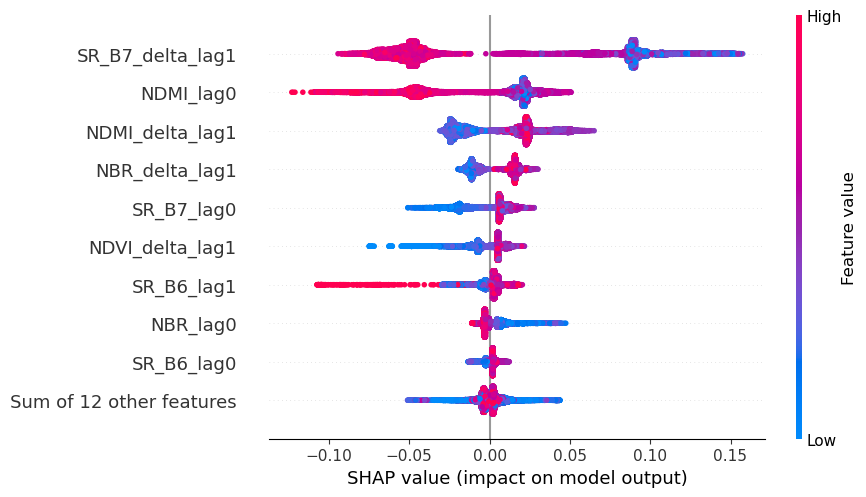

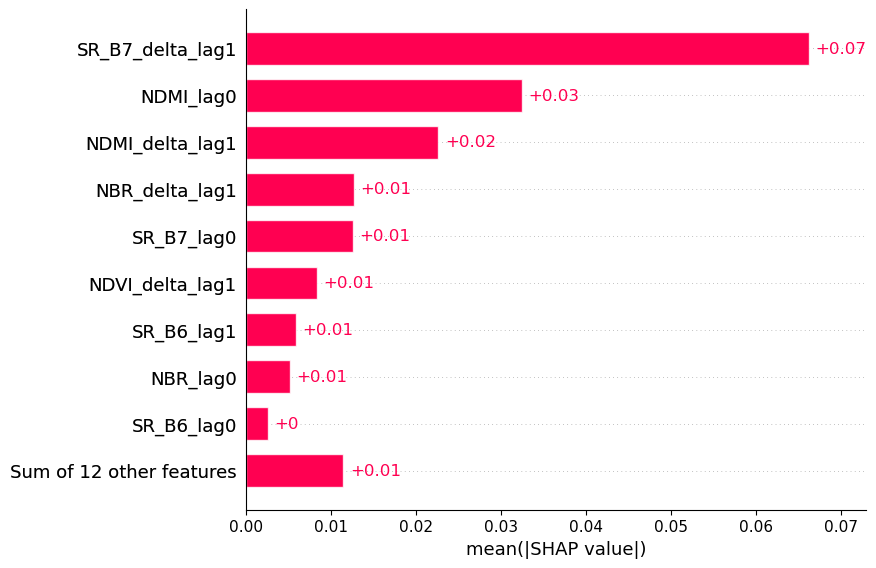

In [21]:
import shap
explainer = shap.Explainer(final_pipe['model'])
# Transform training data for the model component
X_trans = pd.DataFrame(
    final_pipe.named_steps['transformer'].transform(X_train),
    columns=recent_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


In [22]:
print(len(X))

53555


# Test On Holdout Set From the Same Region

In [23]:
amazon_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/testing/amazon_test_2025.csv"), 2025)
taiga_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/testing/taiga_test_2025.csv"), 2025)
borneo_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/testing/borneo_test_2025.csv"), 2025)

print(len(amazon_test))
print(len(taiga_test))
print(len(borneo_test))


5969
6000
5865


In [26]:
X_test_amazon = amazon_test[recent_features]
y_test_amazon = amazon_test['class']
X_test_taiga = taiga_test[recent_features]
y_test_taiga = taiga_test['class']
X_test_borneo = borneo_test[recent_features]
y_test_borneo = borneo_test['class']
print(y_test_borneo.value_counts())

class
1    2951
0    2914
Name: count, dtype: int64


In [27]:
from sklearn.metrics import precision_score, recall_score

print("Amazon Test")
y_test_amazon_pred = final_pipe.predict(X_test_amazon)
print(f"f1: {f1_score(y_test_amazon, y_test_amazon_pred)}")
print(f"precision: {precision_score(y_test_amazon, y_test_amazon_pred)}")
print(f"recall: {recall_score(y_test_amazon, y_test_amazon_pred)}")

print("Taiga Test")
y_test_taiga_pred = final_pipe.predict(X_test_taiga)
print(f"f1: {f1_score(y_test_taiga, y_test_taiga_pred)}")
print(f"precision: {precision_score(y_test_taiga, y_test_taiga_pred)}")
print(f"recall: {recall_score(y_test_taiga, y_test_taiga_pred)}")

print("Borneo Test")
y_test_borneo_pred = final_pipe.predict(X_test_borneo)
print(f"f1: {f1_score(y_test_borneo, y_test_borneo_pred)}")
print(f"precision: {precision_score(y_test_borneo, y_test_borneo_pred)}")
print(f"recall: {recall_score(y_test_borneo, y_test_borneo_pred)}")

print("All Together Test")
X_test = pd.concat([X_test_amazon, X_test_taiga, X_test_borneo])
y_test = pd.concat([y_test_amazon, y_test_taiga, y_test_borneo])
y_test_pred = final_pipe.predict(X_test)
print(f"f1: {f1_score(y_test, y_test_pred)}")
print(f"precision: {precision_score(y_test, y_test_pred)}")
print(f"recall: {recall_score(y_test, y_test_pred)}")

Amazon Test
f1: 0.9054279054279054
precision: 0.9033222591362127
recall: 0.907543391188251
Taiga Test
f1: 0.8611599297012302
precision: 0.826940779380178
recall: 0.8983333333333333
Borneo Test
f1: 0.8366197183098592
precision: 0.870648589226823
recall: 0.8051507963402237
All Together Test
f1: 0.8682084146001672
precision: 0.8657479439875528
recall: 0.8706829104727841


Models do well!

# Test on New Regions

In [30]:
gran_chaco_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/testing/new_forests/gran_chaco_test_2025.csv"), 2025)
se_usa_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/testing/new_forests/se_usa_test_2025.csv"), 2025)
andes_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/testing/new_forests/andes_test_2025.csv"), 2025)

print(len(gran_chaco_test))
print(len(se_usa_test))
print(len(andes_test))

6000
6000
4841


In [31]:
X_test_chaco = gran_chaco_test[recent_features]
y_test_chaco = gran_chaco_test['class']
X_test_se_usa = se_usa_test[recent_features]
y_test_se_usa = se_usa_test['class']
X_test_andes = andes_test[recent_features]
y_test_andes = andes_test['class']
print(y_test_andes.value_counts())

class
1    2749
0    2092
Name: count, dtype: int64


In [32]:
print("Gran Chaco Test")
y_test_chaco_pred = final_pipe.predict(X_test_chaco)
print(f"f1: {f1_score(y_test_chaco, y_test_chaco_pred)}")
print(f"precision: {precision_score(y_test_chaco, y_test_chaco_pred)}")
print(f"recall: {recall_score(y_test_chaco, y_test_chaco_pred)}")

print("SE USA Test")
y_test_se_usa_pred = final_pipe.predict(X_test_se_usa)
print(f"f1: {f1_score(y_test_se_usa, y_test_taiga_pred)}")
print(f"precision: {precision_score(y_test_se_usa, y_test_taiga_pred)}")
print(f"recall: {recall_score(y_test_se_usa, y_test_taiga_pred)}")

print("Andes Test")
y_test_andes_pred = final_pipe.predict(X_test_andes)
print(f"f1: {f1_score(y_test_andes, y_test_andes_pred)}")
print(f"precision: {precision_score(y_test_andes, y_test_andes_pred)}")
print(f"recall: {recall_score(y_test_andes, y_test_andes_pred)}")

print("All Together Test")
X_test = pd.concat([X_test_chaco, X_test_se_usa, X_test_andes])
y_test = pd.concat([y_test_chaco, y_test_se_usa, y_test_andes])
y_test_pred = final_pipe.predict(X_test)
print(f"f1: {f1_score(y_test, y_test_pred)}")
print(f"precision: {precision_score(y_test, y_test_pred)}")
print(f"recall: {recall_score(y_test, y_test_pred)}")

Gran Chaco Test
f1: 0.7882241215574549
precision: 0.9161147902869757
recall: 0.6916666666666667
SE USA Test
f1: 0.519252276721521
precision: 0.49861920834611845
recall: 0.5416666666666666
Andes Test
f1: 0.8776356100198234
precision: 0.8696428571428572
recall: 0.8857766460531102
All Together Test
f1: 0.828886683402417
precision: 0.8471360381861576
recall: 0.811407017944908
